# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 124MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 22.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 30.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.14MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


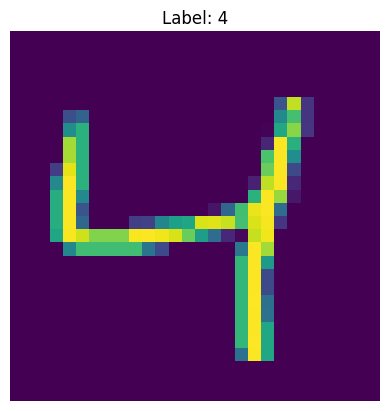

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [6]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5 # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [24]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(20):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.06439834088087082  Accuracy: 96.8087158203125 %
Iteration: 1000  Loss: 0.1053856685757637  Accuracy: 97.00331115722656 %
Iteration: 1500  Loss: 0.06412006914615631  Accuracy: 97.08114624023438 %
Iteration: 2000  Loss: 0.11411017924547195  Accuracy: 97.21735382080078 %
Iteration: 2500  Loss: 0.02593611180782318  Accuracy: 97.1978988647461 %
Iteration: 3000  Loss: 0.05045083910226822  Accuracy: 97.43140411376953 %
Iteration: 3500  Loss: 0.09113200753927231  Accuracy: 97.60653686523438 %
Iteration: 4000  Loss: 0.17982648313045502  Accuracy: 97.64545440673828 %
Iteration: 4500  Loss: 0.05329687520861626  Accuracy: 97.7038345336914 %
Iteration: 5000  Loss: 0.10654731094837189  Accuracy: 97.74275207519531 %
Iteration: 5500  Loss: 0.03169838339090347  Accuracy: 97.78166961669922 %
Iteration: 6000  Loss: 0.11005661636590958  Accuracy: 97.80113220214844 %
Iteration: 6500  Loss: 0.1682462990283966  Accuracy: 97.85950469970703 %
Iteration: 7000  Loss: 0.12254980951547623  

#### **ANN 학습 결과**

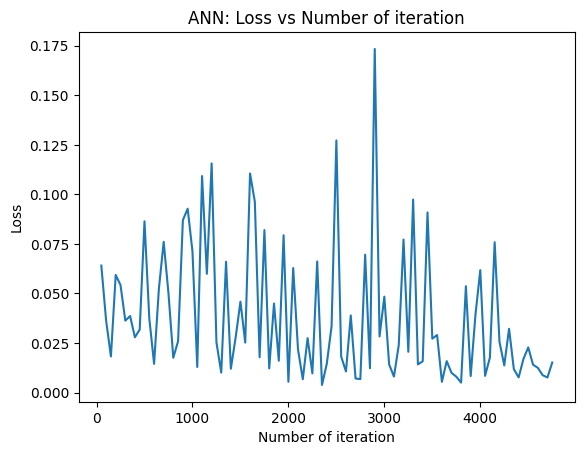

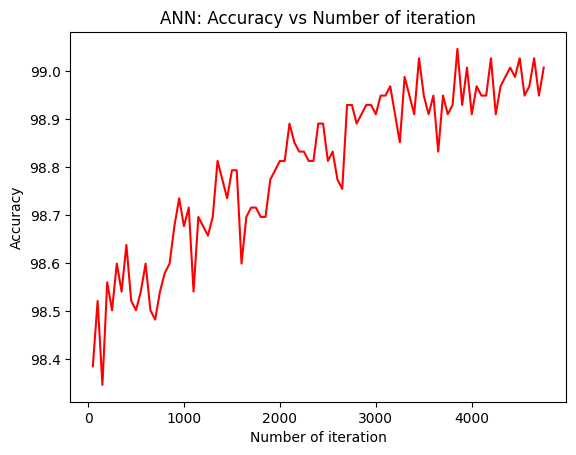

In [11]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- 손실 함수 그래프 (Loss-Number of iteration)

  (1) 전체 iteration 에서 Loss 가 0~0.15 로 낮은 수준임

  (2) 진동이 있긴 하지만 감소하는 경향이 있음.

  => Loss 가 수럼하는 경향성을 보이고 0~0.025 사이의 낮은 수준까지 도달하는 것을 보아 잘 학습되고 있다고 할 수 있다.

- 정확도 그래프(Accuracy-Number of iteration)

  (1) 정확도가 꾸준히 상승하고 있어 최대 99.0% 까지 도달함

  => overfitting 없이 모델이 잘 일반화되고 있음

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [12]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습

hidden_dims = [50, 100, 150, 200]  # hidden_dim 후보 값들

results = {}  # 결과 저장

for hidden_dim in hidden_dims:
    print(f"▶ Hidden dim: {hidden_dim}")

    # 모델 초기화
    model = ANNModel(input_dim=28*28, hidden_dim=hidden_dim, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.02)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    for epoch in range(20):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

    # 결과 저장
    results[hidden_dim] = {
        "iteration": iteration_list,
        "loss": loss_list,
        "accuracy": accuracy_list
    }

▶ Hidden dim: 50
▶ Hidden dim: 100
▶ Hidden dim: 150
▶ Hidden dim: 200


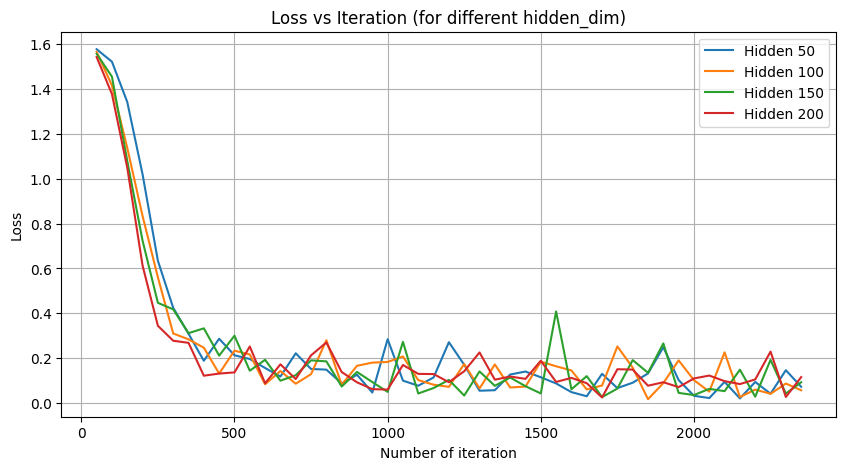

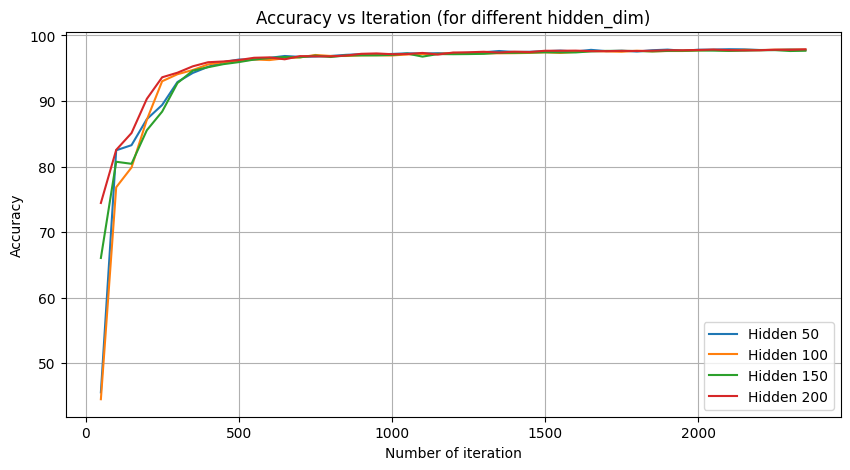

In [13]:
# 실험 1 모델 학습 결과 시각화

# Loss 비교 시각화
plt.figure(figsize=(10,5))
for hidden_dim in results:
    plt.plot(results[hidden_dim]["iteration"], results[hidden_dim]["loss"], label=f"Hidden {hidden_dim}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration (for different hidden_dim)")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy 비교 시각화
plt.figure(figsize=(10,5))
for hidden_dim in results:
    plt.plot(results[hidden_dim]["iteration"], results[hidden_dim]["accuracy"], label=f"Hidden {hidden_dim}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iteration (for different hidden_dim)")
plt.legend()
plt.grid(True)
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- hidden dimension 이 작을수록 accuracy 가 낮은 시점에서 시작해서 비교적 느리게 수렴 지점에 도달하고, loss 감소 또한 큰 hidden demension 인 경우보다 느리게 일어난다.

In [23]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.1, 0.05, 0.01, 0.005]  # learning_rate 후보 값들

results_lr = {}

for lr in learning_rates:
    print(f"▶ Learning Rate: {lr}")

    # 모델 초기화
    model = ANNModel(input_dim=28*28, hidden_dim=150, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    for epoch in range(5):  # 자유롭게 설정 가능
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

    # 결과 저장
    results_lr[lr] = {
        "iteration": iteration_list,
        "loss": loss_list,
        "accuracy": accuracy_list
    }

▶ Learning Rate: 0.1
▶ Learning Rate: 0.05
▶ Learning Rate: 0.01
▶ Learning Rate: 0.005


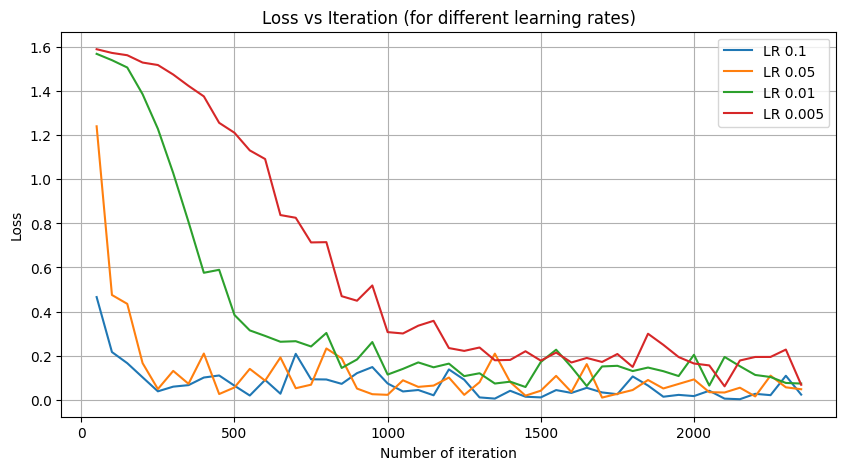

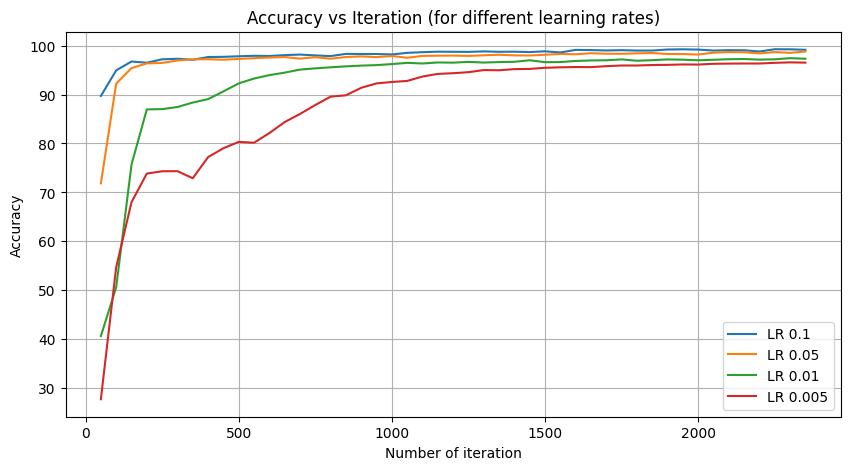

In [15]:
# 실험 2 모델 학습 결과 시각화

# Loss 비교 시각화
plt.figure(figsize=(10,5))
for lr in results_lr:
    plt.plot(results_lr[lr]["iteration"], results_lr[lr]["loss"], label=f"LR {lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration (for different learning rates)")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy 비교 시각화
plt.figure(figsize=(10,5))
for lr in results_lr:
    plt.plot(results_lr[lr]["iteration"], results_lr[lr]["accuracy"], label=f"LR {lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iteration (for different learning rates)")
plt.legend()
plt.grid(True)
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
learning rate 가 클수록 loss 가 더 빠르게 감소하고 정확도도 더 빠르게 상승하는 경향을 볼 수 있다. 너무 큰 learning rate는 발산 위험이 있지만 현재 실험에서는 0.05~0.1 사이의 learning rate 가 가장 효과적임.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU() # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [17]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [20]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.21079380027094316
Epoch 2, Loss: 0.11451449011897742
Epoch 3, Loss: 0.09670135369116055
Epoch 4, Loss: 0.08291111237103108
Epoch 5, Loss: 0.07303833631052012
Epoch 6, Loss: 0.06495453433438918
Epoch 7, Loss: 0.05857020751660639
Epoch 8, Loss: 0.052980732298135325
Epoch 9, Loss: 0.04878658223032002
Epoch 10, Loss: 0.04560818481365985
Epoch 11, Loss: 0.04211229041737887
Epoch 12, Loss: 0.04000521407487932
Epoch 13, Loss: 0.03741355255437676
Epoch 14, Loss: 0.03554601225606312
Epoch 15, Loss: 0.03387854339764891
Epoch 16, Loss: 0.032651051840468334
Epoch 17, Loss: 0.030703092002191255
Epoch 18, Loss: 0.029747579810486636
Epoch 19, Loss: 0.02838252215439139
Epoch 20, Loss: 0.027576214402995708


#### **CNN 학습 결과**

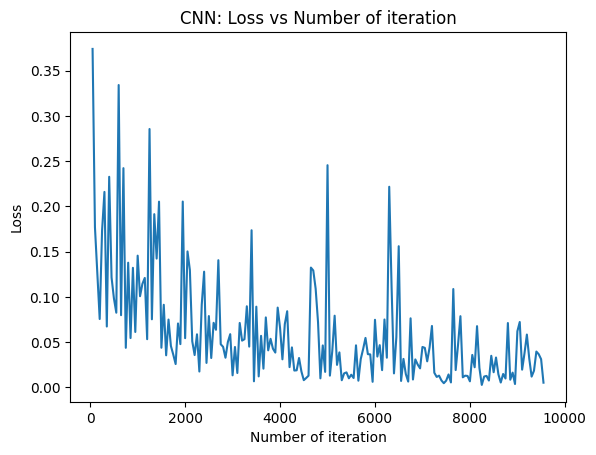

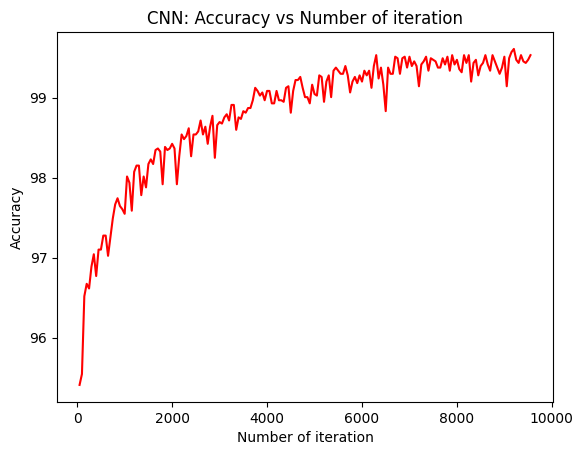

In [21]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN (Artificial Neural Network) 입력층과 여러 개의 은닉층, 출력층으로 구성된 신경망. 이미지의 공간적 구조를 고려하지 않고 픽셀을 1차원 벡터로 펼쳐 처리하기 때문에 이미지의 위치나 형태 정보 손실이 있을 수 있음.
- CNN(Convolutional Neural Network) : 활성화 함수, 풀링, 완전연결층으로 구성되며 이미지의 공간적 정보를 보존하면서도 특징을 자동으로 추출할 수 있다.
- 결과 비교 : ANN 은 정확도 98~99%, CNN 은 정확도 99% 이상으로 두 모델 모두 좋은 정확도을 보이나, CNN 이 이미지 분류에 최적화된 구조로 좀 더 좋은 정확도를 보임. 하지만 같은 epoch 20 기준 학습 시간이 ANN 의 경우 3분 정도, CNN 은 10분 이상으로 훨씬 오래 걸리는 것을 확인할 수 있었다.
